# Нейронные сети








# Метод обратного распространения ошибки

Обучение нелинейного нейрона.  Проблема обучения нелинейного нейрона в скрытом слое состоит в том, что для адаптации параметров нейрона нужно знать ошибку на выходе нейрона.

Последовательность перехода сигнала определяется конструкцией нейрона и характеристикой, которую обеспечивает активационная функция.  



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# sklearn здесь только, чтобы разделить выборку на тренировочную и тестовую
from sklearn.model_selection import train_test_split

##  Проблемы обучения нелинейного нейрона

Нейрон для анализа - логистического типа. Определим основные функции для обработки:

- to_one_hot(Y) : преобразует значение в вектор по правилу one-hot-encoding ( пример при 10 классах, значение Y=4 переведем в вектор <0, 0, 0, 0, 1, 0, 0, 0, 0, 0 >),

- from_one_hot(Y) : переводит вектор one-hot-encoding в значение скалярного типа (вектор Y <0, 0, 0, 0, 1, 0, 0, 0, 0, 0 > переводится в значение 4)

- sum_neuron(x=None, w=None) : вернет свертку векторов x, w - на выходе скалярное значение - внутреннее состояние нейрона,

-  sigmoid_complex_neuron(x = None, w = None, bias=0, lymbd = 1) : логистический нейрон с входным набором значений х  и настраиваемыми параметрами w.

- sigmoid_deriv(g) : производная логистического нейрона,

- normalize(X, axis=-1, order=2) : нормализация признаков - делаем входы удобными для нейрона

### **Задание 1**

1.1 реализовать функции to_one_hot(Y), from_one_hot(Y), sum_neuron(x=None, w=None), sigmoid_complex_neuron(x = None, w = None, bias=0, lymbd = 1), sigmoid_deriv(g), normalize(X, axis=-1, order=2)

1.2 визуализировать результат работы sigmoid_complex_neuron(x = None, w = None, bias=0, lymbd = 1), sigmoid_deriv(g)

**Обратное распространение ошибки:**

1. описание модели и данных: число эпох, веса, скорость обучения, разделение данных на тест, валидацию и тренировку

2. Подготовка тренировочных данных

3. Обученние нейронной сети

3.1. прямое распространение(feed forward)

3.2. оценка ошибки на выходе

3.3.1 получение значения производной активационнной функции текущего слоя

3.3.2 получение оценки ошибки на выходе предшествующего слоя

3.3.3 коррекция весов текущего слоя

3.3.4 переход к предшествующему слою если он не является рецептивным , иначе конец шага 3.3

3.4 проверка числа эпох: если необходимое число эпох отработано, то конец шага 3., иначе вернуться к 3.1.

4. Оценка результатов на тестовом множестве



### **Задание 2**

2.1. Реализовать цикл работы для обучения модели по оратному распространению ошибки на примере ирисов Фишера

2.2. визуализировать результаты

In [10]:
### Шаг 2. Подготовка тренировочных данных
# получения данных из csv файла. укажите здесь путь к файлу Iris.csv
data = load_iris()

# формирование входных данных

x = data['data']
x = normalize(x)

# формирование выходных данных(результатов)

y = data['target']

y = y.flatten()
y = to_one_hot(y)

# Разделение данных на тренировочные и тестовые
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33)

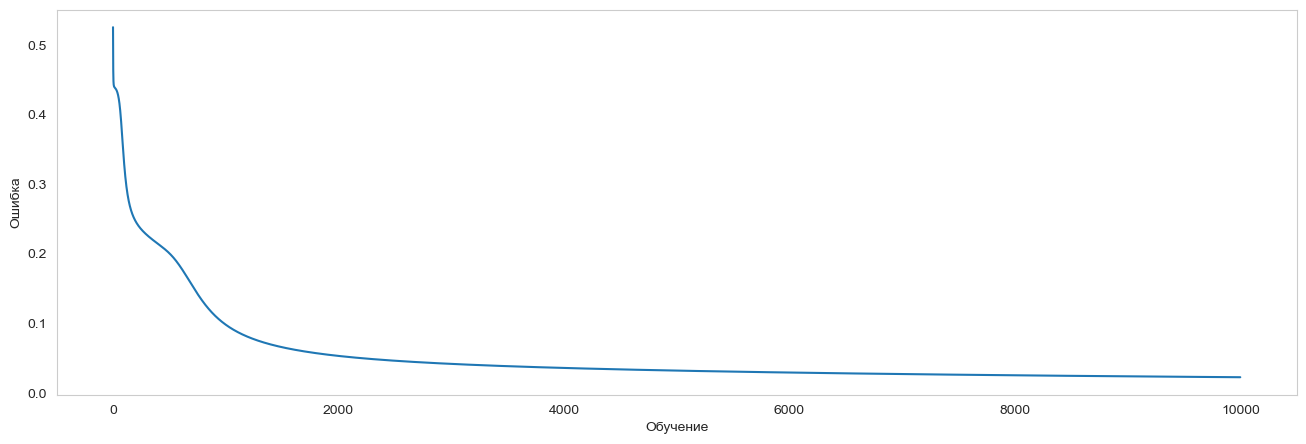

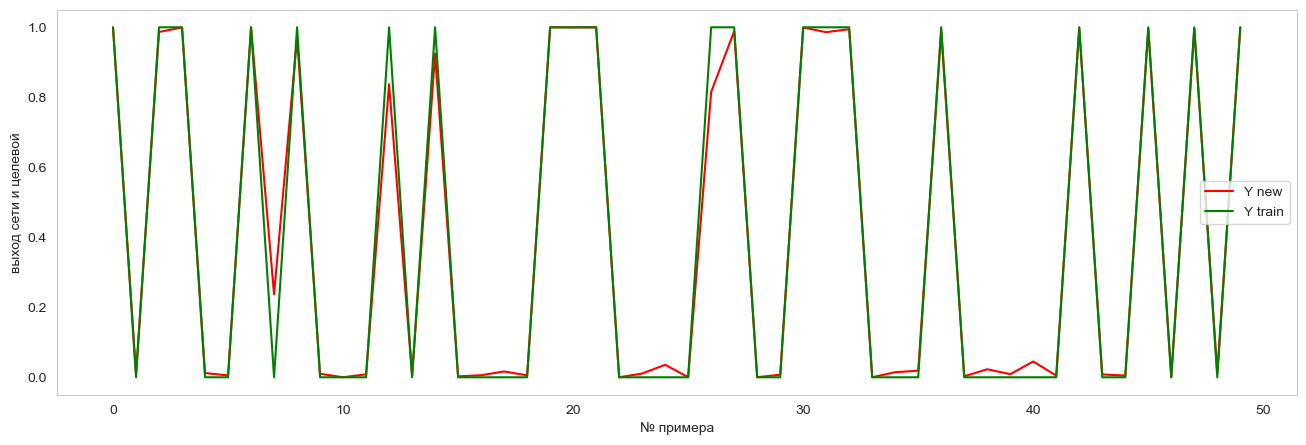

Аккуратность нейронной сети 97.76%


In [15]:
### Шаг 3. Обученние нейронной сети

# определим число нейронов скрытого слоя
neuron_numb = 5

# присваевание случайных весов

w0 = 2*np.random.random((4, neuron_numb)) - 1 # для входного слоя   - 4 входа, 3 выхода
w1 = 2*np.random.random((neuron_numb, 3)) - 1 # для внутреннего слоя - 5 входов, 3 выхода

# скорость обучения (learning rate)
n = 0.05

# массив для ошибок, чтобы потом построить график
errors = []

# процесс обучения
for i in range(10000):
    # прямое распространение(feed forward)
    layer0 = X_train
    layer1 = sigmoid(np.dot(layer0, w0))
    layer2 = sigmoid(np.dot(layer1, w1))
#   ...


### Шаг 4. Демонстрация полученных результатов
# черчение диаграммы точности в зависимости от обучения
plt.figure(figsize = (16,5))
plt.plot(errors)
plt.xlabel('Обучение')
plt.ylabel('Ошибка')
plt.grid()
plt.show() # расскоментируйте, чтобы посмотреть

N = 50
plt.figure(figsize = (16,5))
plt.plot(layer2[:N,1], 'r',label = 'Y new')
plt.plot(y_train[:N,1],'g', label = 'Y train')
plt.xlabel('№ примера')
plt.ylabel('выход сети и целевой')
plt.legend( )
plt.grid()
plt.show() # расскоментируйте, чтобы посмотреть

print("Аккуратность нейронной сети " + str(round(accuracy,2)) + "%")

In [ ]:
w1

array([[  5.54999251,   2.21321665, -15.19461242],
       [ -2.59445837,  -2.77378166,  -1.58190113],
       [  2.81145216,  -6.8404759 ,  -4.13083826],
       [ -5.55101451, -19.40488958,  12.91513902],
       [ -7.07277246,  12.42234602,   2.87944655]])

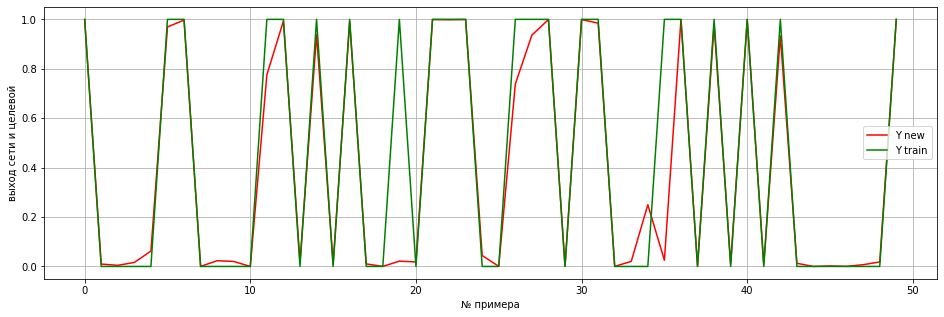

Аккуратность нейронной сети на тесте 95.78%


In [ ]:
# прямое распространение(feed forward)
layer0_t = X_test
# ...


N = 50
plt.figure(figsize = (16,5))
plt.plot(layer2_t[:N,1], 'r',label = 'Y new')
plt.plot(y_test[:N,1],'g', label = 'Y train')
plt.xlabel('№ примера')
plt.ylabel('выход сети и целевой')
plt.grid()
plt.legend( )
plt.show() # расскоментируйте, чтобы посмотреть

# метрика модели
error_t = np.mean(np.abs(layer2_error_t))
accuracy_t = (1 - error_t) * 100
print("Аккуратность нейронной сети на тесте " + str(round(accuracy_t,2)) + "%")

## Практическое задание

Используем набор примеров load_digits

1.  Опишите - какой результата получен в нейросети в зависимости от:
  - числа нейронов в слое(для 2-хслойной сети),
  - шага обучения в диапазоне [10.0**(-5), 10.0].
  - фиксируйте для тренировочного и тестового набора метрики accuracy.
2. Сделайте вывод - что помогло вам улучшить качество классификации в нейросети на тестовом наборе?

3. Для одного варианта сетей сформируйте матрицу ошибок по классам. Оцените качество модели по каждому классу отдельно (полнота , точность). Сделайте вывод.